In [121]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

In [122]:
df = pd.read_csv('Daily_Water_Intake.csv')

In [123]:
df.shape

(30000, 7)

In [124]:
df.head()

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
4,38,Male,77,2.11,Low,Normal,Poor


In [125]:
df = df.rename(
            {
                'Weight (kg)' : 'Weight',
                'Daily Water Intake (liters)' : 'Daily Water Intake'
            },
            axis = 1
        )

In [126]:
df.head()

,Age,Gender,Weight,Daily Water Intake,Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
4,38,Male,77,2.11,Low,Normal,Poor


In [127]:
df.info() # Looks clean

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      30000 non-null  int64  
 1   Gender                   30000 non-null  object 
 2   Weight                   30000 non-null  int64  
 3   Daily Water Intake       30000 non-null  float64
 4   Physical Activity Level  30000 non-null  object 
 5   Weather                  30000 non-null  object 
 6   Hydration Level          30000 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.6+ MB


In [128]:
df.nunique()

Age                         52
Gender                       2
Weight                      65
Daily Water Intake         390
Physical Activity Level      3
Weather                      3
Hydration Level              2
dtype: int64

In [129]:
''' 
Binary Encoding : Gender , Hydration Level
Ordinal Encoding : Physical Activity Level
OneHotEncoding : Weather
'''

' \nBinary Encoding : Gender , Hydration Level\nOrdinal Encoding : Physical Activity Level\nOneHotEncoding : Weather\n'

In [130]:
# Plan is to use Logistic Regression here using these columns , for now and maybe Random Forest Later

In [131]:
# There can be anamolies in numeric columns also we need to find the ratio of the categorical columns before_hand to know whether the dataset is imbalanced or not

In [132]:
df['Hydration Level'].value_counts() # As doubted is imbalanced , when splitting into training and testing set we will be stratifying y so every split get the same proportion of values

Hydration Level
Good    23915
Poor     6085
Name: count, dtype: int64

In [133]:
df['Gender'].value_counts() # Balanced it is 

Gender
Male      15032
Female    14968
Name: count, dtype: int64

In [134]:
# Now quickly let's check the distribution of the dataset

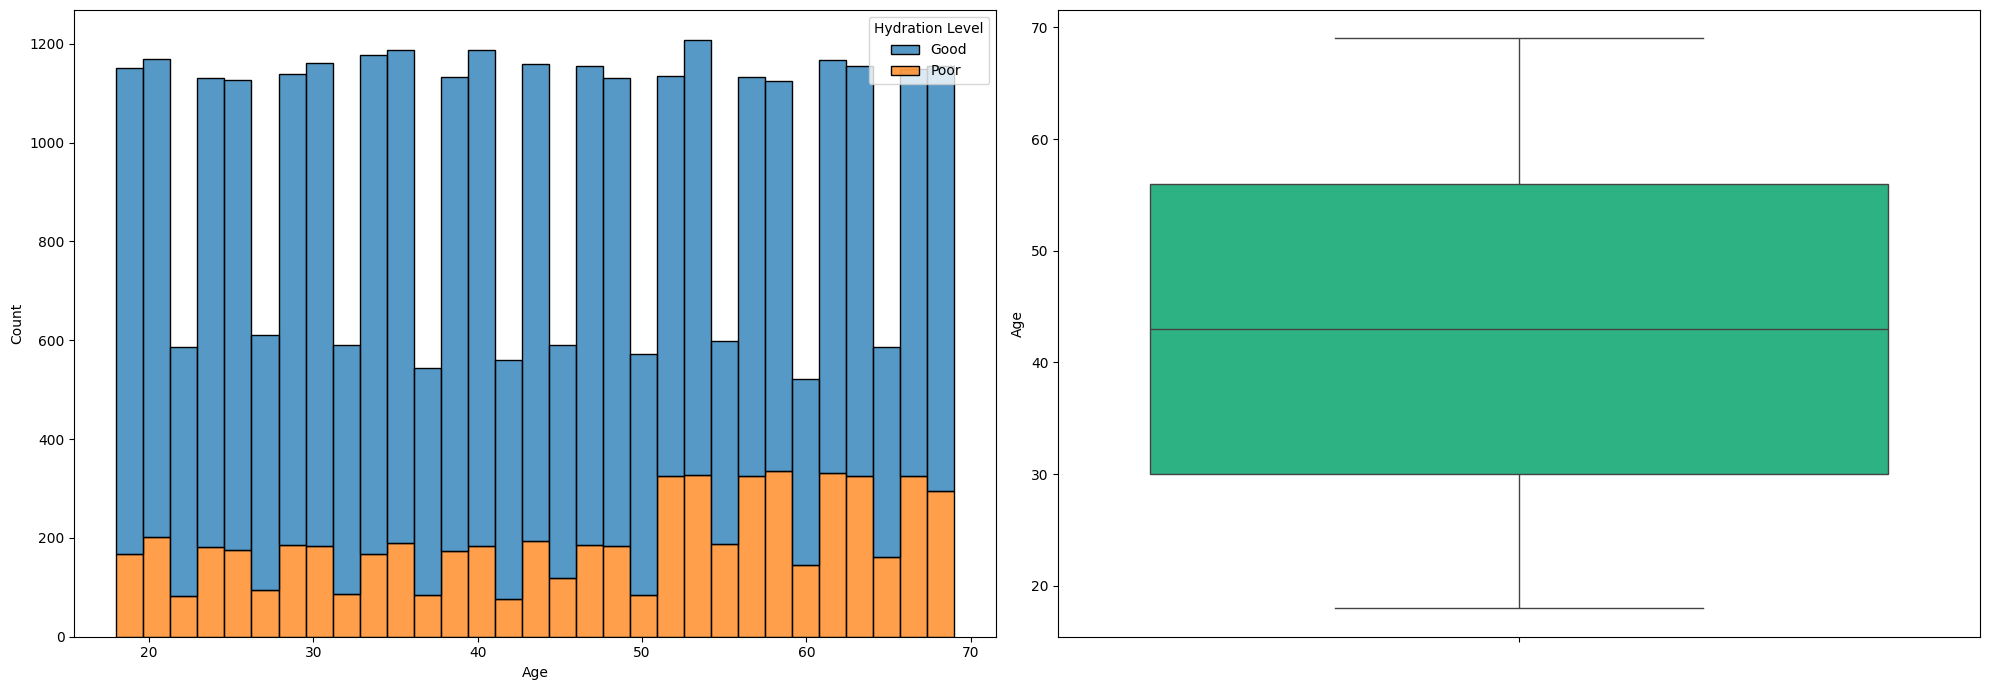

In [135]:
# First let us look at the age column
plt.figure(figsize=(20,7))

plt.subplot(121)
sns.histplot(
                df,
                x='Age',
                hue='Hydration Level',
                multiple='stack'
            )

plt.subplot(122)
sns.boxplot(
                df,
                y='Age',
                color = "#17C88A"
            )

plt.tight_layout()
plt.show()

# The age is distributed uniformly acorss the range and also the range itself is valid there are no anamolies,outliers like age -10 or age 150

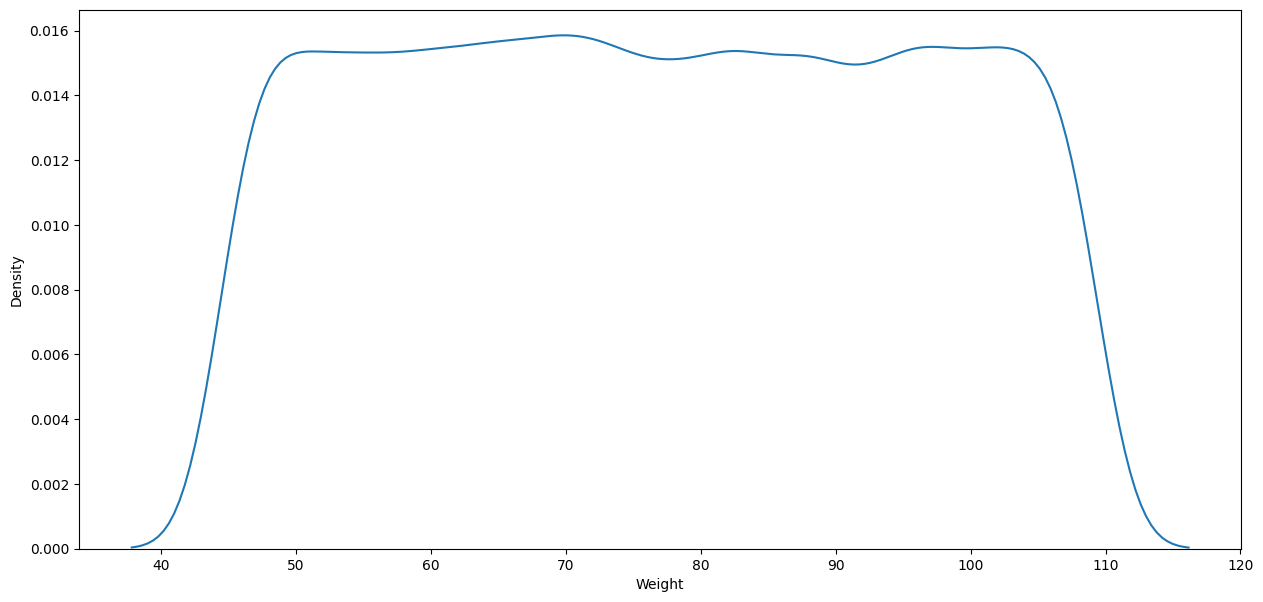

In [136]:
# Now let's move on to the weight distribution
plt.figure(figsize=(15,7))
sns.kdeplot(
                df,
                x='Weight',
            )
plt.show()
# Weight also is uniformly distributed well and there seem no outliers

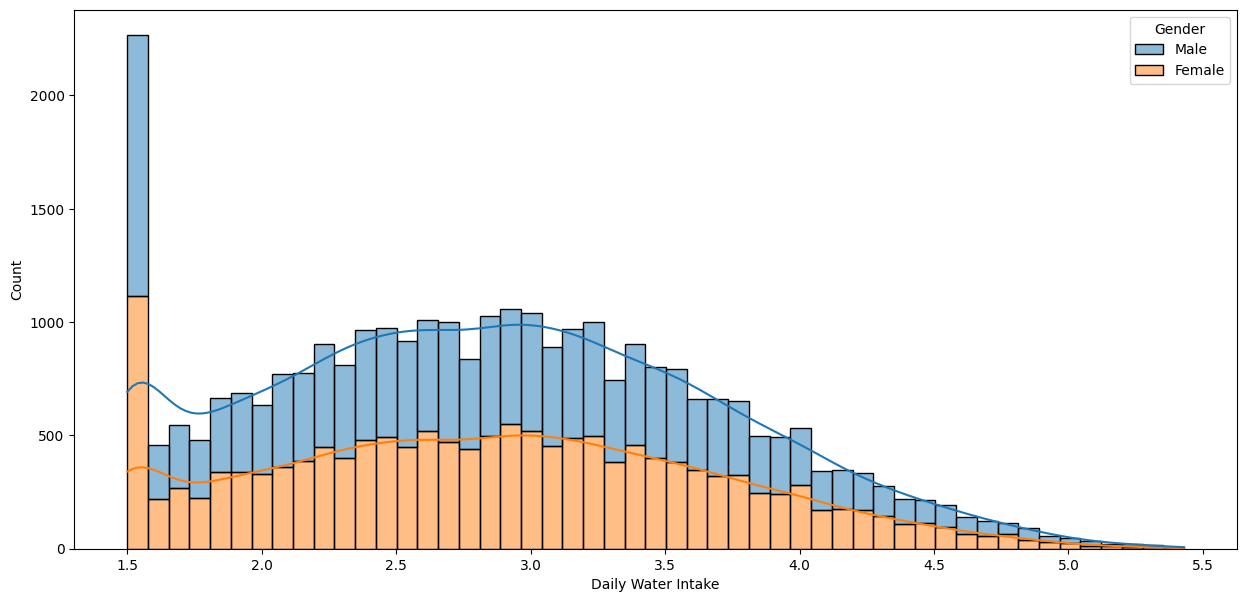

In [137]:
plt.figure(figsize=(15,7))
sns.histplot(
                df,
                x='Daily Water Intake',
                kde = True,
                hue = 'Gender',
                multiple = 'stack'
            )
plt.show()

In [138]:
# Import observation found that many of the people drink around 1.5 L of water everyday.
# Also the gender distribution seems equal for each bin

In [139]:
# Also I have found out that the other columns are balanced as well

In [140]:
# In conclusion the data was actually well maintained and really well for our dataset
# We can move on with converting the string values to numeric using maps and encoding

In [141]:
df.head

<bound method NDFrame.head of        Age  Gender  Weight  Daily Water Intake Physical Activity Level  \
0       56    Male      96                4.23                Moderate   
1       60    Male     105                3.95                    High   
2       36    Male      68                2.39                Moderate   
3       19  Female      74                3.13                Moderate   
4       38    Male      77                2.11                     Low   
...    ...     ...     ...                 ...                     ...   
29995   47    Male      97                3.45                Moderate   
29996   49  Female     109                5.32                    High   
29997   56  Female      54                1.50                Moderate   
29998   36    Male     106                4.00                     Low   
29999   26  Female      98                4.43                Moderate   

      Weather Hydration Level  
0         Hot            Good  
1      Normal    

In [142]:
df['Gender'] = df['Gender'].map(
                    {
                            'Male' : 1,
                            'Female' : 0
                    }
)

In [143]:
df['Physical Activity Level'].unique()

array(['Moderate', 'High', 'Low'], dtype=object)

In [144]:
# In Physical Activity Level there is purely a heirarchy so we map according to heirarchy
df['Physical Activity Level'] = df['Physical Activity Level'].map(
                                                    {
                                                        'Moderate': 1,
                                                        'High' : 2,
                                                        'Low': 0
                                                    }
                                                )

In [145]:
df['Hydration Level'] = df['Hydration Level'].map(
                    {
                            'Good' : 1,
                            'Poor' : 0
                    }
)

In [146]:
df = pd.get_dummies(df,'Weather',dtype=int)

In [147]:
df.head()

,Age,Gender,Weight,Daily Water Intake,Physical Activity Level,Hydration Level,Weather_Cold,Weather_Hot,Weather_Normal
0,56,1,96,4.23,1,1,0,1,0
1,60,1,105,3.95,2,1,0,0,1
2,36,1,68,2.39,1,1,1,0,0
3,19,0,74,3.13,1,1,0,1,0
4,38,1,77,2.11,0,0,0,0,1


In [148]:
# Now splitting 
X,y = df.drop(columns=['Hydration Level']),df['Hydration Level']

In [150]:
# Now while splitting for training and testing set make sure to stratify y 
X_train , X_test , y_train , y_test = train_test_split(
                                                        X,y,
                                                        test_size = 0.3,
                                                        stratify = y,
                                                        random_state = 42
)